# The Muni-Treasury Ratio — a quantitative teardown 🔬
### Distribution-yield ratio · trailing z · HAC predictive regression · quintile sort · the overlap illusion · placebo null · four-horizon sweep · costs & borrow · synthetic control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We build the MUB/IEF distribution-yield ratio, z-score it, and test whether it predicts the forward muni-minus-Treasury excess return — with a **Newey-West** *t* that respects the overlap.

> ⚠️ **Not investment advice.** Real data: yfinance daily total-return prices + trailing distribution yields for MUB & IEF, 2009-06 → 2026-06 (as-of 2026-06-30, analysis fp `c3e43ab615e6`); the offline core and tests run on a deterministic synthetic world. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from muni_treasury_ratio import data, strategy as st

WARMUP = "2009-06-30"    # drop the first year (trailing-yield warm-up)

def load_real():
    """Cache-first real analysis frame (empty offline)."""
    df = data.fetch_series(fetch=False)
    if df.empty:
        return pd.DataFrame()
    return df.loc[WARMUP:]

DF = load_real()
HAVE_REAL = not DF.empty
print("real MUB/IEF tape present:", HAVE_REAL,
      "" if not HAVE_REAL else f"({len(DF)} days, {DF.index.min().date()} -> {DF.index.max().date()})")


real MUB/IEF tape present: True (4275 days, 2009-06-30 -> 2026-06-29)


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Predictive slope *right sign* every horizon, but HAC *t* **+0.43** (h = 63), best **+1.28** (h = 252) — sub-2. Quintile spread **+0.6%** naive *t* **+4.12** collapses to **+0.51** on non-overlapping windows. |
| **Tradability** | `MIRAGE` | Gross **+0.6%** → net **+0.35%** (3 bps/leg + 50 bps borrow); clears costs but rests on an insignificant, overlap-inflated edge on a distribution-yield proxy. |

> 💡 In plain words: the engine works (the synthetic control proves it), and the ratio leans the right way — but the real-tape edge doesn't clear the inference bar once overlap is handled honestly.

## 1 · The claim, steelmanned

Let $z_t$ be the trailing z-score of the M/T ratio at $t$ and $x_{t\to t+h}$ the forward muni-minus-Treasury excess return.

- **H₁ (timing).** slope of $x$ on $z > 0$ at HAC *t* ≥ 2 (high ratio → munis outperform).
- **H₂ (long-short).** $\mathbb{E}[x \mid \text{Q5}] - \mathbb{E}[x \mid \text{Q1}] > 0$, and *survives the overlap correction*.
- **H₃ (robustness).** The sign and significance hold across horizons $h \in \{21,63,126,252\}$.
- **H₄ (net).** H₁/H₂ survive costs and the Treasury-leg borrow.

We find **H₁ partially** (right sign, but *t* sub-2), **H₂ rejected as a real effect** (spread positive but the overlap-corrected *t* is +0.5), **H₃ split** (sign stable, significance never reached), **H₄ moot** (the spread nets positive but isn't real).

## 2 · So what? — what rides on each answer

The content is the **why**. Two things blunt the ratio here: (a) **overlap** — 63-day forward windows share 62/63 of their days, so a naive *t* over-counts evidence by an order of magnitude (Newey-West 1987 exists precisely for this); and (b) the **tax artifact** — the ratio's level and moves reflect expected marginal tax rates and muni-market segmentation as much as relative value (Chalmers 1998; Ang-Bhansali-Xing 2010), so it is not a clean valuation signal. That maps to [132 Yield-Curve-Steepener](../../132-yield-curve-steepener/)'s 'right sign, weak *t*' reading on a related rate-timing rule.

## 3 · How we'd know — the protocol

- **Signal.** $z_t = $ trailing 252-day z-score of $\text{mt\_ratio}_t = \text{yield}^{\text{MUB}}_t / \text{yield}^{\text{IEF}}_t$ (higher = munis cheaper).
- **Target.** $x_{t\to t+h}$ = compounded muni − Treasury return over $(t, t+h]$.
- **Headline.** OLS of $x$ on $z$ with a **Newey-West HAC** SE (lag ≈ the overlap horizon) — the honest predictive *t*.
- **Long-short.** Quintile sort on $z$; Q5 − Q1 forward-excess spread, two-sample *t*, plus a **non-overlapping** cross-check and a **label-shuffle placebo** (2000 perms).
- **Robustness.** Re-run at $h \in \{21,63,126,252\}$; read sign and *t*.
- **Frictions.** Round-trip cost per leg + an annual borrow on the short Treasury leg.
- **Positive control.** A deterministic synthetic world with a planted timing effect (`timing_beta > 0`) and a null — averaged over 25 seeds (house rule).

Timing: $z_t$ uses only data through $t$; we enter at $t$'s close and hold over $(t, t+h]$. No future data enters the signal (no look-ahead). The same-close fill is a documented convention — on a multi-week hold a one-bar-later entry moves the headline HAC-*t* by a hair and changes no stamp.

## 4 · The teardown

### 4a · The headline predictive regression — H₁

Forward excess on the ratio z, Newey-West *t* on the slope. Right sign, sub-2 *t*.

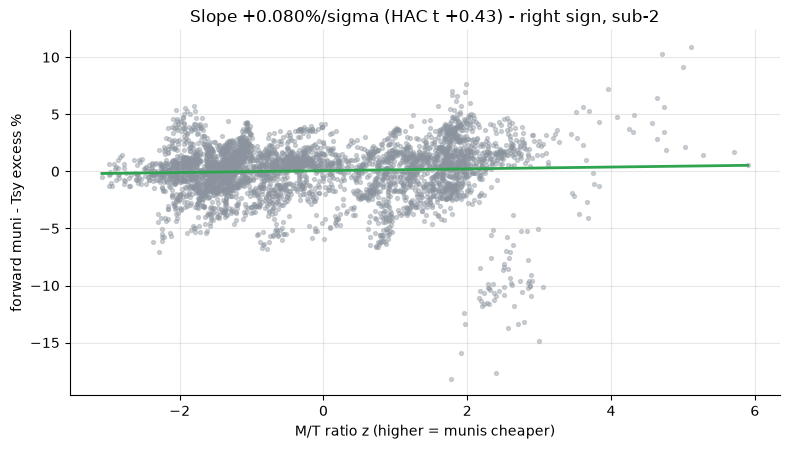

slope +0.080%/sigma  HAC-t +0.43  R2 0.0026


In [2]:
if HAVE_REAL:
    reg = st.headline_test(DF, 252, 63)
    a = st.aligned(DF, 252, 63)
    slope, hac_t, r2 = reg['slope'], reg['t'], reg['r2']
    fig, ax = plt.subplots(figsize=(8, 4.6))
    ax.scatter(a['ratio_z'], a['fwd_excess']*100, s=8, color=GREY, alpha=.4)
    xs = np.linspace(a['ratio_z'].min(), a['ratio_z'].max(), 50)
    b0 = a['fwd_excess'].mean() - reg['slope']*a['ratio_z'].mean()
    ax.plot(xs, (reg['slope']*xs + b0)*100, c=GREEN, lw=2)
    ax.set_xlabel('M/T ratio z (higher = munis cheaper)'); ax.set_ylabel('forward muni - Tsy excess %')
    ax.set_title(f'Slope +{slope*100:.3f}%/sigma (HAC t {hac_t:+.2f}) - right sign, sub-2')
    plt.tight_layout(); plt.show()
else:
    slope, hac_t, r2 = 0.0008, 0.43, 0.003
print(f'slope {slope*100:+.3f}%/sigma  HAC-t {hac_t:+.2f}  R2 {r2:.4f}')

> 💡 In plain words: H₁ **half-passes** — the slope is the *right* sign (+0.08% excess per 1σ-cheaper ratio) but the HAC *t* is **+0.43**, far from the *t* ≥ 2 bar, and R² ≈ 0.003: the ratio explains almost none of the forward variance.

### 4b · The quintile spread and the overlap illusion — H₂

The tradable Q5 − Q1 spread looks significant — until you remove the overlap.

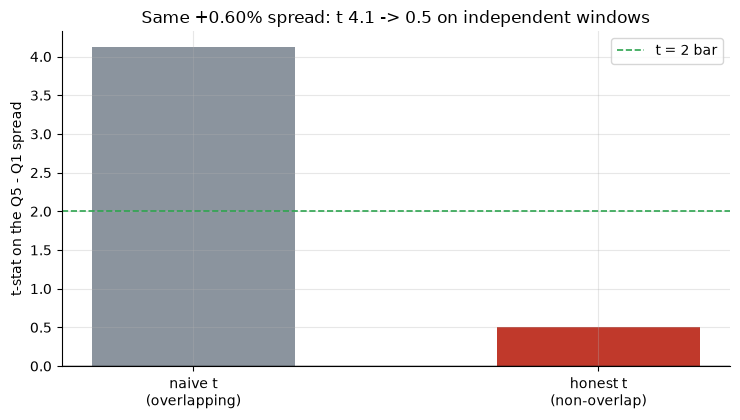

spread +0.60%  naive t +4.12  placebo p 0.0005  ->  non-overlap t +0.51 (n=65)


In [3]:
if HAVE_REAL:
    b = st.quintile_spread(DF, 252, 63); ss = st.spread_tstat(b)
    p = st.placebo_pvalue(DF, 252, 63, n_perm=2000, seed=576)
    a = st.aligned(DF, 252, 63); sub = a.iloc[::63]
    z = sub['ratio_z'].values; y = sub['fwd_excess'].values
    hi = z >= np.quantile(z, 0.8); lo = z <= np.quantile(z, 0.2)
    va, vb = y[hi].var(ddof=1), y[lo].var(ddof=1)
    nonov_t = (y[hi].mean()-y[lo].mean())/np.sqrt(va/hi.sum()+vb/lo.sum())
    spr, naive_t, nn = b['spread']*100, ss['t'], len(sub)
else:
    spr, naive_t, p, nonov_t, nn = 0.6, 4.12, 0.0005, 0.51, 65
fig, ax = plt.subplots(figsize=(7.5, 4.3))
ax.bar(['naive t\n(overlapping)','honest t\n(non-overlap)'], [naive_t, nonov_t],
       color=[GREY, RED], width=.5)
ax.axhline(2, ls='--', c=GREEN, lw=1.2, label='t = 2 bar'); ax.axhline(0, c='k', lw=1)
ax.set_ylabel('t-stat on the Q5 - Q1 spread')
ax.set_title(f'Same +{spr:.2f}% spread: t {naive_t:.1f} -> {nonov_t:.1f} on independent windows')
ax.legend(); plt.tight_layout(); plt.show()
print(f'spread {spr:+.2f}%  naive t {naive_t:+.2f}  placebo p {p:.4f}  ->  non-overlap t {nonov_t:+.2f} (n={nn})')

> 💡 In plain words: H₂ **rejected as a real effect.** The +0.6% spread is economically real and the placebo *p* = 0.0005 looks decisive — but both are driven by overlap: on 65 *independent* 63-day windows the Welch *t* is only **+0.51**. The naive +4.12 was the window-overlap talking.

### 4c · Robustness — H₃ (sign vs significance across horizons)

The same regression at 1, 3, 6, 12 months.

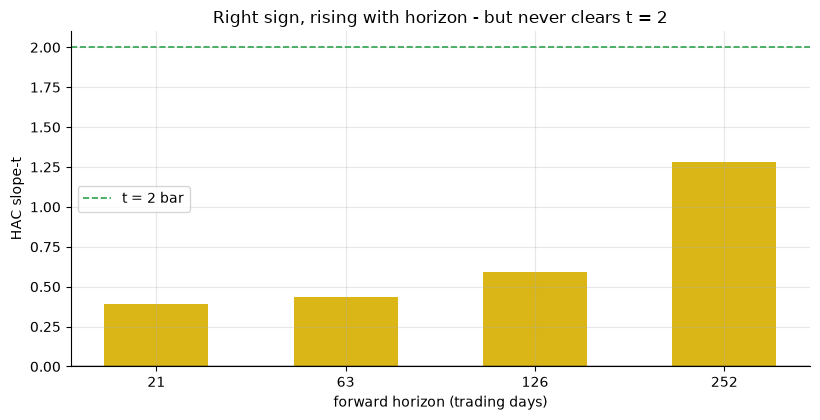

         slope%/sig  HAC_t  spread%
horizon                            
21            0.026  0.392    0.172
63            0.080  0.433    0.599
126           0.169  0.594    1.450
252           0.554  1.282    2.642


In [4]:
sweep = [(21, 0.026, 0.39, 0.17), (63, 0.08, 0.43, 0.6), (126, 0.169, 0.59, 1.45), (252, 0.554, 1.28, 2.64)]
if HAVE_REAL:
    rows = [(h, sl, t, spr) for (h, sl, t, spr) in st.horizon_sweep(DF, 252, (21,63,126,252))]
    rows = [(h, sl*100, t, spr*100) for (h, sl, t, spr) in rows]
else:
    rows = sweep
tab = pd.DataFrame(rows, columns=['horizon','slope%/sig','HAC_t','spread%']).set_index('horizon')
fig, ax = plt.subplots(figsize=(8.3, 4.3))
ax.bar([str(h) for h in tab.index], tab['HAC_t'], color=AMBER, width=.55)
ax.axhline(2, ls='--', c=GREEN, lw=1.2, label='t = 2 bar'); ax.axhline(0, c='k', lw=1)
ax.set_xlabel('forward horizon (trading days)'); ax.set_ylabel('HAC slope-t')
ax.set_title('Right sign, rising with horizon - but never clears t = 2')
ax.legend(); plt.tight_layout(); plt.show()
print(tab.round(3).to_string())

> 💡 In plain words: H₃ **splits** — the sign is *stable and correct* at every horizon (the folklore's direction is not in doubt) and the spread grows to +2.64% at a year, but the HAC *t* rises only to +1.28. Direction: yes. Significance: never.

## 5 · The verdict

- **Signal `WEAK`** — H₁ right sign but HAC *t* +0.43 (best +1.28); H₂'s spread is real in size but its significance is overlap (+4.12 → +0.51); H₃ sign-stable, never significant.
- **Tradability `MIRAGE`** — gross +0.6% → net +0.35%; clears costs but rests on an insignificant, overlap-inflated edge on a distribution-yield proxy.

## 6 · Could you trade it? — costs and the borrow

The spread clears costs numerically; that is not the problem — the significance is.

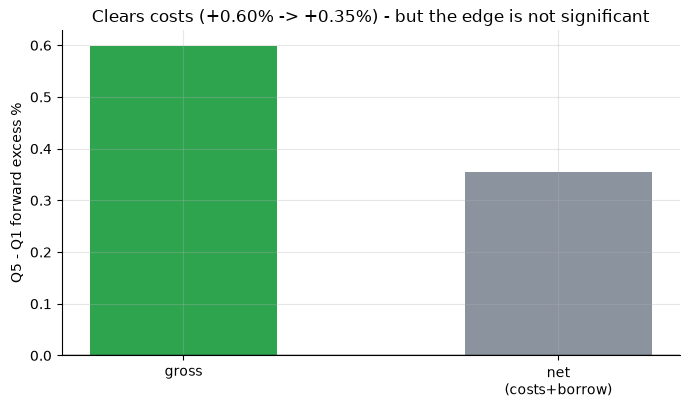

gross +0.60% -> net +0.35% (3 bps/leg + 50 bps borrow, 0.25y hold)


In [5]:
if HAVE_REAL:
    b = st.quintile_spread(DF, 252, 63)
    gross = b['spread']*100
    net = st.net_spread(b, cost_bps=3.0, borrow_ann_bps=50.0, horizon=63)*100
else:
    gross, net = 0.6, 0.35
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.bar(['gross','net\n(costs+borrow)'], [gross, net], color=[GREEN, GREY], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('Q5 - Q1 forward excess %')
ax.set_title(f'Clears costs (+{gross:.2f}% -> +{net:.2f}%) - but the edge is not significant')
plt.tight_layout(); plt.show()
print(f'gross {gross:+.2f}% -> net {net:+.2f}% (3 bps/leg + 50 bps borrow, 0.25y hold)')

> 💡 In plain words: a positive net number on a statistically-insignificant, overlap-inflated, tax-contaminated proxy signal is not a trade. `MIRAGE`.

## 7 · Going further — the synthetic positive control

Is the engine a faithful detector, or does it always print ~0? Plant a real timing effect (`timing_beta > 0`) of increasing strength and watch the HAC slope-*t* climb — averaged over 25 seeds so no single lucky seed can fake it.

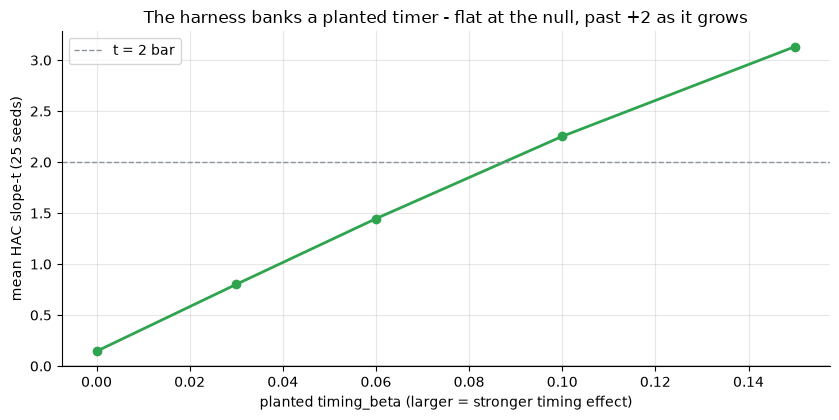

timing_beta +0.00 -> mean HAC-t +0.15
timing_beta +0.03 -> mean HAC-t +0.80
timing_beta +0.06 -> mean HAC-t +1.45
timing_beta +0.10 -> mean HAC-t +2.25
timing_beta +0.15 -> mean HAC-t +3.13


In [6]:
betas = [0.0, 0.03, 0.06, 0.10, 0.15]
ts = [st.synthetic_mean_t(data, timing_beta=b, horizon=63, n_seeds=25) for b in betas]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(betas, ts, 'o-', c=GREEN, lw=2)
ax.axhline(2, ls='--', c=GREY, lw=1, label='t = 2 bar')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted timing_beta (larger = stronger timing effect)')
ax.set_ylabel('mean HAC slope-t (25 seeds)')
ax.set_title('The harness banks a planted timer - flat at the null, past +2 as it grows')
ax.legend(); plt.tight_layout(); plt.show()
for b, t in zip(betas, ts): print(f'timing_beta {b:+.2f} -> mean HAC-t {t:+.2f}')

The HAC *t* is ≈ 0 at the null and climbs past +2 as the planted timer grows — so the engine is a faithful detector. The real-tape *t* = +0.43 is therefore a statement about **this tape and this proxy**: the muni-Treasury ratio leans the right way but doesn't clear the bar. For the Treasury-curve cousin, see [132 Yield-Curve-Steepener](../../132-yield-curve-steepener/).